In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from sklearn.metrics import classification_report, confusion_matrix, mean_squared_error, mean_absolute_error, r2_score

In [3]:
df = pd.read_excel('/content/datosmediolimpio.xlsx')

In [4]:
df.head()

,TRANSACTION ID,FECHA NACIMIENTO,FECHA EXP DOC,NIVEL ESTUDIOS,ESTADOCIVIL,PROFESION,GÉNERO,TIPO VIVIENDA,NO PERSONAS A CARGO,ANTIGUEDAD EN LA CIUDAD tiempo en residencia,...,SCORE,SEGURO,AVAL,CODIGO CONFIRMACION CREDITO,PAGARE_ID,NUMERO CREDITO TESEO,SALDO CAPITAL,SALDO VENCIDO,DIAS DE MORA,FRANJA DE MORA
0,2016918,1983-07-18,2001-07-27 05:00:00,Universitario,Soltero (a),Ingeniero,M,Familiar,0.0,3.0,...,649,20986,69958,768277,40322901.0,768277,0,0.0,0,01. Al dia
1,2016914,1965-04-15,1983-08-16 05:00:00,Técnico,Soltero (a),Contador,F,Propia,0.0,21.0,...,843,7712,25710,50199432,40322628.0,50199432,5141500,0.0,0,01. Al dia
2,2016836,2005-01-25,2023-01-31 05:00:00,Técnico,Unión libre,Educador,F,Familiar,0.0,15.0,...,630,1889,6295,26657430,40321155.0,26657430,1259000,0.0,0,01. Al dia
3,2016736,1995-11-15,2013-11-28 00:00:00,Técnico,Unión libre,Asesor,F,Propia,0.0,7.0,...,754,3822,12741,81389650,40318689.0,81389650,2492576,0.0,0,01. Al dia
4,2016576,2006-11-20,2024-11-27 00:00:00,Universitario,Soltero (a),Ingeniero,F,Propia,0.0,19.0,...,503,2816,9387,57688111,40310628.0,57688111,1840083,0.0,0,01. Al dia


In [5]:
df.describe()

,TRANSACTION ID,FECHA NACIMIENTO,FECHA EXP DOC,NO PERSONAS A CARGO,ANTIGUEDAD EN LA CIUDAD tiempo en residencia,ESTRATO,TIEMPO ACTIVIDAD,INGRESOS FIJOS,OTROS INGRESOS,TOTAL INGRESOS,...,FCREACION DENTICUOTAS,SCORE,SEGURO,AVAL,CODIGO CONFIRMACION CREDITO,PAGARE_ID,NUMERO CREDITO TESEO,SALDO CAPITAL,SALDO VENCIDO,DIAS DE MORA
count,4.632800e+04,46328,46328,22040.000000,46326.000000,46326.000000,46326.000000,4.632700e+04,9.665000e+03,1.677700e+04,...,46328,46328.000000,46328.000000,46328.000000,4.632800e+04,4.578900e+04,4.632800e+04,4.632800e+04,4.632800e+04,46328.000000
mean,1.483516e+06,1984-12-14 20:49:39.122776768,2003-10-25 12:07:26.036953984,0.247777,10.246620,3.276087,8.984151,7.007981e+06,1.599548e+06,9.444231e+06,...,2022-10-17 04:01:06.913184256,636.499288,5739.378734,14492.891772,4.483156e+07,2.178600e+07,4.261213e+07,1.696566e+06,9.444248e+05,17.730314
min,1.173594e+06,1945-09-17 00:00:00,1948-03-18 00:00:00,0.000000,0.500000,1.000000,0.500000,3.200000e+05,0.000000e+00,3.200000e+05,...,2021-04-05 00:00:00,-8.000000,405.000000,675.000000,1.860000e+02,0.000000e+00,1.860000e+02,0.000000e+00,0.000000e+00,0.000000
25%,1.307609e+06,1974-07-03 00:00:00,1993-08-30 15:30:00,0.000000,4.000000,3.000000,3.000000,2.400000e+06,2.500000e+05,3.500000e+06,...,2021-11-29 00:00:00,599.000000,2730.000000,5291.000000,1.150800e+07,1.521833e+07,1.097004e+07,0.000000e+00,0.000000e+00,0.000000
50%,1.387568e+06,1988-01-06 00:00:00,2006-09-09 00:00:00,0.000000,8.000000,3.000000,6.500000,3.500000e+06,1.000000e+06,5.500000e+06,...,2022-05-12 00:00:00,684.000000,4787.000000,9549.000000,4.100085e+07,1.905503e+07,4.036212e+07,2.539820e+05,0.000000e+00,0.000000
75%,1.664454e+06,1997-04-29 00:00:00,2015-11-17 00:00:00,0.000000,19.000000,4.000000,14.500000,5.900000e+06,2.000000e+06,9.000000e+06,...,2023-08-26 15:04:36.500000,761.000000,7401.000000,18698.000000,7.036076e+07,2.850011e+07,6.998099e+07,2.718848e+06,1.643132e+05,8.000000
max,2.049921e+06,2009-09-11 00:00:00,2025-06-04 05:00:00,11.000000,21.000000,6.000000,21.000000,1.900000e+10,7.000000e+07,1.400000e+10,...,2025-08-11 18:45:10,999.000000,37500.000000,193375.000000,9.861105e+09,4.160793e+07,9.999960e+07,2.500000e+07,4.546752e+07,1559.000000
std,2.261208e+05,NaN,NaN,0.632896,7.357605,1.037316,6.908594,1.629172e+08,2.169734e+06,1.425309e+08,...,NaN,219.446036,4503.266098,14868.910258,1.352178e+08,8.142428e+06,3.119803e+07,2.662800e+06,2.551413e+06,78.897157


In [6]:
df.shape

(46328, 54)

In [7]:
missing_values = df.isnull().sum()
missing_values

,0
TRANSACTION ID,0
FECHA NACIMIENTO,0
FECHA EXP DOC,0
NIVEL ESTUDIOS,2
ESTADOCIVIL,2
PROFESION,2
GÉNERO,1188
TIPO VIVIENDA,2
NO PERSONAS A CARGO,24288
ANTIGUEDAD EN LA CIUDAD tiempo en residencia,2


In [8]:
#df = df.dropna()

In [9]:
features = []
for col in df.columns:
  t = str(df[col].dtype)
  if "int" in t or "float" in t:
    features.append(col)
features = features[1:]

In [10]:
features

['NO PERSONAS A CARGO',
 'ANTIGUEDAD EN LA CIUDAD tiempo en residencia',
 'ESTRATO',
 'TIEMPO ACTIVIDAD',
 'INGRESOS FIJOS',
 'OTROS INGRESOS',
 'TOTAL INGRESOS',
 'CUOTA DE CREDITOS',
 'GASTOS DE SOSTENIMIENTO',
 'TOTAL EGRESOS',
 'ACTIVOS',
 'PASIVOS',
 'MONTO PREAPROBADO',
 'NO CREDITO',
 'MONTO APROBADO',
 'PLAZO',
 'MONTO DESEMBOLSO',
 'IDENTIFICACION COMERCIAL',
 'TASA',
 'CUOTAMENSUAL',
 'CODIGO CIIU',
 'OPERACION MONEDA EXTRAGERA',
 'SCORE',
 'SEGURO',
 'AVAL',
 'CODIGO CONFIRMACION CREDITO',
 'PAGARE_ID',
 'NUMERO CREDITO TESEO',
 'SALDO CAPITAL',
 'SALDO VENCIDO',
 'DIAS DE MORA ']

In [11]:
data = df[features]

In [12]:
corr = data.corr()
corr

,NO PERSONAS A CARGO,ANTIGUEDAD EN LA CIUDAD tiempo en residencia,ESTRATO,TIEMPO ACTIVIDAD,INGRESOS FIJOS,OTROS INGRESOS,TOTAL INGRESOS,CUOTA DE CREDITOS,GASTOS DE SOSTENIMIENTO,TOTAL EGRESOS,...,OPERACION MONEDA EXTRAGERA,SCORE,SEGURO,AVAL,CODIGO CONFIRMACION CREDITO,PAGARE_ID,NUMERO CREDITO TESEO,SALDO CAPITAL,SALDO VENCIDO,DIAS DE MORA
NO PERSONAS A CARGO,1.000000,-0.087734,-0.162883,0.023182,-0.010917,-0.025841,-0.004858,0.166315,0.008214,0.082795,...,0.054350,0.074849,-0.080776,-0.189763,-0.089241,-0.487149,-0.147685,-0.111247,0.019212,-0.003077
ANTIGUEDAD EN LA CIUDAD tiempo en residencia,-0.087734,1.000000,0.053985,0.328406,0.012941,0.163572,0.022908,-0.002562,0.004161,-0.045353,...,-0.009612,0.063173,0.085917,0.094479,0.003976,0.089612,0.026954,0.048277,-0.010117,-0.007190
ESTRATO,-0.162883,0.053985,1.000000,0.144062,0.018453,0.157595,0.007285,-0.002419,-0.001490,0.041171,...,-0.003796,0.085706,0.129273,0.135089,0.010514,0.137431,0.044225,0.058875,-0.013792,-0.022318
TIEMPO ACTIVIDAD,0.023182,0.328406,0.144062,1.000000,0.021636,0.154038,0.015910,0.010037,0.007918,0.023261,...,-0.004646,0.278790,0.195975,0.185173,0.008328,0.116577,0.016127,0.080269,-0.018012,-0.018954
INGRESOS FIJOS,-0.010917,0.012941,0.018453,0.021636,1.000000,0.463613,0.999918,-0.000218,-0.000109,-0.003324,...,-0.001260,0.003782,0.028034,0.022101,-0.000561,0.005855,-0.000662,0.020097,0.023611,0.005283
OTROS INGRESOS,-0.025841,0.163572,0.157595,0.154038,0.463613,1.000000,0.711828,0.084886,-0.009556,0.008736,...,NaN,0.058857,0.199770,0.188584,-0.013664,0.070249,-0.024371,0.156815,0.028247,0.000030
TOTAL INGRESOS,-0.004858,0.022908,0.007285,0.015910,0.999918,0.711828,1.000000,-0.001101,-0.002909,-0.003020,...,NaN,-0.001392,0.014281,0.019007,-0.001732,-0.007554,-0.001711,0.001895,-0.002154,-0.001750
CUOTA DE CREDITOS,0.166315,-0.002562,-0.002419,0.010037,-0.000218,0.084886,-0.001101,1.000000,-0.000109,0.370440,...,0.087640,0.004124,0.001001,-0.002758,-0.003578,-0.009692,-0.006395,-0.004629,-0.002358,-0.001606
GASTOS DE SOSTENIMIENTO,0.008214,0.004161,-0.001490,0.007918,-0.000109,-0.009556,-0.002909,-0.000109,1.000000,0.961633,...,0.003195,0.003099,-0.000759,-0.002123,-0.000391,-0.003743,-0.001327,-0.002876,-0.001044,-0.001154
TOTAL EGRESOS,0.082795,-0.045353,0.041171,0.023261,-0.003324,0.008736,-0.003020,0.370440,0.961633,1.000000,...,NaN,0.061931,0.005162,0.005662,-0.007694,0.000878,-0.011207,-0.007107,-0.010948,-0.010366


<Axes: >

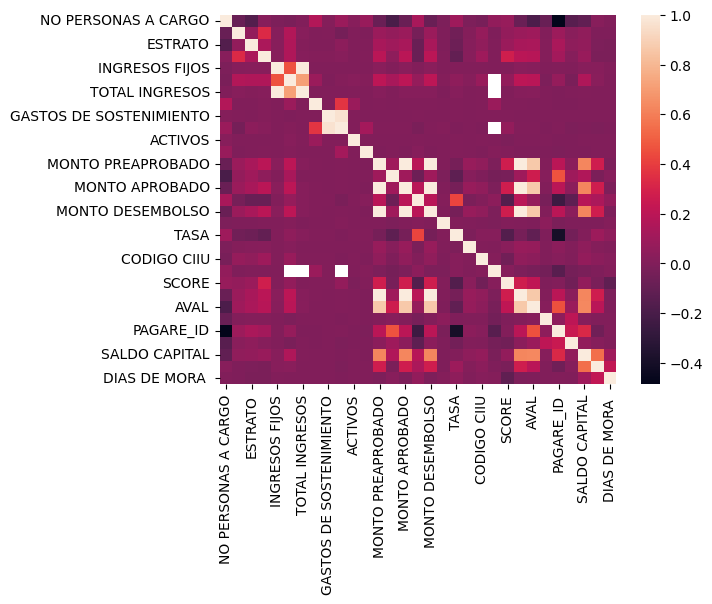

In [13]:
sns.heatmap(corr)

In [14]:
relevant_features = []
for col in corr.columns:
  for row in corr.index:
    if col != row:
      corr_value = corr.loc[row, col]

      if abs(corr_value) > 0.5:
        if col not in relevant_features:
          relevant_features.append(col)
relevant_features

['INGRESOS FIJOS',
 'OTROS INGRESOS',
 'TOTAL INGRESOS',
 'GASTOS DE SOSTENIMIENTO',
 'TOTAL EGRESOS',
 'MONTO PREAPROBADO',
 'MONTO APROBADO',
 'MONTO DESEMBOLSO',
 'SEGURO',
 'AVAL',
 'SALDO CAPITAL',
 'SALDO VENCIDO']

In [15]:
data = data[relevant_features]
data = data.drop(columns = ['AVAL', 'SEGURO'])

In [16]:
data = data.dropna()

In [17]:
corr = data.corr()
corr

,INGRESOS FIJOS,OTROS INGRESOS,TOTAL INGRESOS,GASTOS DE SOSTENIMIENTO,TOTAL EGRESOS,MONTO PREAPROBADO,MONTO APROBADO,MONTO DESEMBOLSO,SALDO CAPITAL,SALDO VENCIDO
INGRESOS FIJOS,1.000000,0.463613,0.952325,0.004028,0.012151,0.289627,0.289627,0.289627,0.201111,0.033393
OTROS INGRESOS,0.463613,1.000000,0.711828,-0.009556,0.008736,0.199760,0.199760,0.199760,0.156815,0.028247
TOTAL INGRESOS,0.952325,0.711828,1.000000,-0.000097,0.012640,0.298367,0.298367,0.298367,0.213414,0.036196
GASTOS DE SOSTENIMIENTO,0.004028,-0.009556,-0.000097,1.000000,0.977610,-0.002136,-0.002136,-0.002136,0.000570,-0.000917
TOTAL EGRESOS,0.012151,0.008736,0.012640,0.977610,1.000000,0.006828,0.006828,0.006828,0.002869,-0.004311
MONTO PREAPROBADO,0.289627,0.199760,0.298367,-0.002136,0.006828,1.000000,1.000000,1.000000,0.708528,0.259159
MONTO APROBADO,0.289627,0.199760,0.298367,-0.002136,0.006828,1.000000,1.000000,1.000000,0.708528,0.259159
MONTO DESEMBOLSO,0.289627,0.199760,0.298367,-0.002136,0.006828,1.000000,1.000000,1.000000,0.708528,0.259159
SALDO CAPITAL,0.201111,0.156815,0.213414,0.000570,0.002869,0.708528,0.708528,0.708528,1.000000,0.452930
SALDO VENCIDO,0.033393,0.028247,0.036196,-0.000917,-0.004311,0.259159,0.259159,0.259159,0.452930,1.000000


<Axes: >

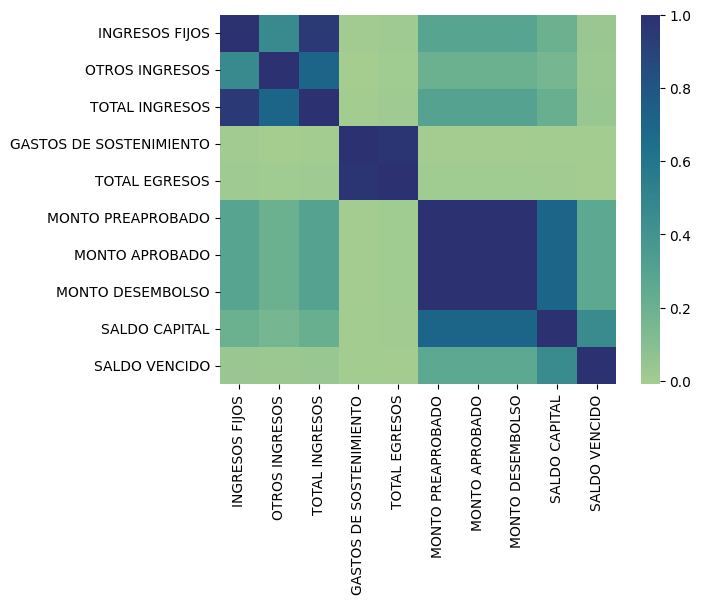

In [18]:
sns.heatmap(corr, cmap = "crest")

# Regresión linear

In [19]:
X1 = data[['MONTO APROBADO', 'SALDO CAPITAL']]

In [20]:
y1 = data['INGRESOS FIJOS']

In [21]:
reg = LinearRegression().fit(X1, y1)

In [22]:
reg.score(X1, y1)

0.08391747017052187

In [23]:
X2 = data[['INGRESOS FIJOS', 'OTROS INGRESOS', 'TOTAL EGRESOS', 'SALDO CAPITAL']]

In [24]:
y2 = data['MONTO APROBADO']

In [25]:
reg = LinearRegression().fit(X2, y2)
reg.score(X2, y2)

0.5252245710047321

In [26]:
X3 = data[['TOTAL INGRESOS', 'GASTOS DE SOSTENIMIENTO']]

In [27]:
y3 = data['TOTAL EGRESOS']

In [28]:
y4 = data['SALDO CAPITAL']

In [29]:
reg = LinearRegression().fit(X3, y3)
reg.score(X3, y3)

0.9558834015687643

In [30]:
reg = LinearRegression().fit(X3, y4)
reg.score(X3, y4)

0.04554599318244723

In [31]:
#X5 = data[['SEGURO', 'AVAL', 'MONTO APROBADO']]

In [32]:
#y5 = data['MONTO DESEMBOLSO']

In [33]:
#reg = LinearRegression().fit(X5, y5)
#reg.score(X5, y5)

In [34]:
X6 = data[['MONTO APROBADO', 'TOTAL INGRESOS']]

In [35]:
y6 = data['SALDO VENCIDO']

In [36]:
reg = LinearRegression().fit(X6, y6)
reg.score(X6, y6)

0.06902000459468471

# Creación de nuevas variables

In [37]:
data['INDICE ENDEUDAMIENTO'] = data['TOTAL EGRESOS'] / data['TOTAL INGRESOS']

## Regresión Linear con Var. Nueva

# PCA

# Avance 2

## Modelo de Mora

In [38]:
mora_30 = []
for mora in df['DIAS DE MORA ']:
  if mora >= 30:
    mora_30.append(1)
  else:
    mora_30.append(0)

In [39]:
mora_30 = pd.DataFrame(mora_30)

In [40]:
data['MORA DE MAS DE 30 DIAS'] = mora_30

In [41]:
data.head()

,INGRESOS FIJOS,OTROS INGRESOS,TOTAL INGRESOS,GASTOS DE SOSTENIMIENTO,TOTAL EGRESOS,MONTO PREAPROBADO,MONTO APROBADO,MONTO DESEMBOLSO,SALDO CAPITAL,SALDO VENCIDO,INDICE ENDEUDAMIENTO,MORA DE MAS DE 30 DIAS
0,13000000.0,2500000.0,15500000.0,35000.0,60000.0,13990500,13990500,13990500,0,0.0,0.003871,0
3,4000000.0,3500000.0,7500000.0,600000.0,800000.0,2548000,2548000,2548000,2492576,0.0,0.106667,0
9,6000000.0,4500000.0,10500000.0,500000.0,1000000.0,3154500,3154500,3154500,3154500,0.0,0.095238,0
10,5000000.0,3500000.0,8500000.0,600000.0,750000.0,5760000,5760000,5760000,5604430,0.0,0.088235,0
11,2000000.0,0.0,2000000.0,100000.0,100000.0,747000,747000,747000,747000,0.0,0.050000,0


## Logistic Regression

In [42]:
X_mora = data.drop(columns = ['MORA DE MAS DE 30 DIAS', 'MONTO DESEMBOLSO', 'SALDO VENCIDO'])
y_mora = data['MORA DE MAS DE 30 DIAS']

In [43]:
X_mora.head()

,INGRESOS FIJOS,OTROS INGRESOS,TOTAL INGRESOS,GASTOS DE SOSTENIMIENTO,TOTAL EGRESOS,MONTO PREAPROBADO,MONTO APROBADO,SALDO CAPITAL,INDICE ENDEUDAMIENTO
0,13000000.0,2500000.0,15500000.0,35000.0,60000.0,13990500,13990500,0,0.003871
3,4000000.0,3500000.0,7500000.0,600000.0,800000.0,2548000,2548000,2492576,0.106667
9,6000000.0,4500000.0,10500000.0,500000.0,1000000.0,3154500,3154500,3154500,0.095238
10,5000000.0,3500000.0,8500000.0,600000.0,750000.0,5760000,5760000,5604430,0.088235
11,2000000.0,0.0,2000000.0,100000.0,100000.0,747000,747000,747000,0.050000


In [44]:
X_mora_train, X_mora_test, y_mora_train, y_mora_test = train_test_split(X_mora, y_mora, test_size = 0.2, random_state = 88)

In [45]:
scaler_mora = StandardScaler()
X_mora_train = scaler_mora.fit_transform(X_mora_train)
X_mora_test = scaler_mora.transform(X_mora_test)

In [46]:
modelo_mora = LogisticRegression()
modelo_mora.fit(X_mora_train, y_mora_train)

LogisticRegression()

In [47]:
y_pred_mora = modelo_mora.predict(X_mora_test)

In [48]:
print(classification_report(y_mora_test, y_pred_mora))

              precision    recall  f1-score   support

           0       0.81      1.00      0.90      1569
           1       0.50      0.00      0.01       364

    accuracy                           0.81      1933
   macro avg       0.66      0.50      0.45      1933
weighted avg       0.75      0.81      0.73      1933



In [49]:
cm = confusion_matrix(y_mora_test, y_pred_mora)

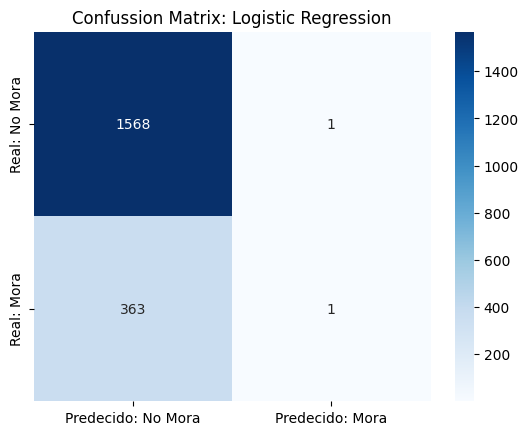

In [50]:
sns.heatmap(cm,
            annot = True,
            fmt = "d",
            cmap = "Blues",
            xticklabels = ['Predecido: No Mora', 'Predecido: Mora'],
            yticklabels = ['Real: No Mora', 'Real: Mora'])
plt.title('Confussion Matrix: Logistic Regression')
plt.show()

## Random Forest

In [51]:
modelo_rf = RandomForestRegressor(n_estimators = 500, random_state = 55)
modelo_rf.fit(X_mora_train, y_mora_train)

RandomForestRegressor(n_estimators=500, random_state=55)

In [52]:
y_pred_rf = modelo_rf.predict(X_mora_test)

In [53]:
y_pred_rf_binary = (y_pred_rf >= 0.3).astype(int)
print(classification_report(y_mora_test, y_pred_rf_binary))

              precision    recall  f1-score   support

           0       0.85      0.81      0.83      1569
           1       0.32      0.38      0.34       364

    accuracy                           0.73      1933
   macro avg       0.58      0.59      0.59      1933
weighted avg       0.75      0.73      0.74      1933



In [54]:
importancia = modelo_rf.feature_importances_

In [55]:
indice = np.argsort(importancia)[::-1]
indice

array([7, 5, 6, 8, 2, 0, 1, 4, 3])

In [56]:
features_importantes = X_mora.columns[indice]
features_importantes

Index(['SALDO CAPITAL', 'MONTO PREAPROBADO', 'MONTO APROBADO',
       'INDICE ENDEUDAMIENTO', 'TOTAL INGRESOS', 'INGRESOS FIJOS',
       'OTROS INGRESOS', 'TOTAL EGRESOS', 'GASTOS DE SOSTENIMIENTO'],
      dtype='object')

In [57]:
cm_rf = confusion_matrix(y_mora_test, y_pred_rf_binary)

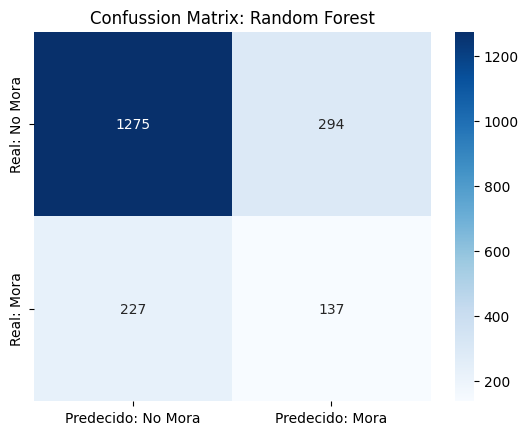

In [58]:
sns.heatmap(cm_rf,
            annot = True,
            fmt = "d",
            cmap = "Blues",
            xticklabels = ['Predecido: No Mora', 'Predecido: Mora'],
            yticklabels = ['Real: No Mora', 'Real: Mora'])
plt.title('Confussion Matrix: Random Forest')
plt.show()

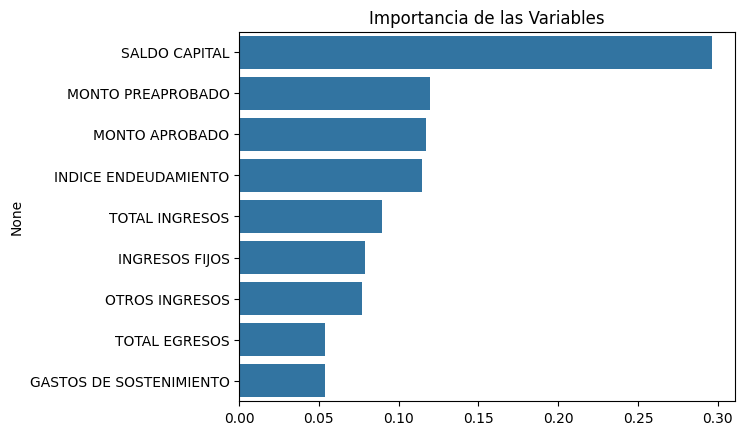

In [59]:
sns.barplot(x = importancia[indice], y = features_importantes)
plt.title('Importancia de las Variables')
plt.show()

## Menos variables

In [61]:
X_mora_better = X_mora[['SALDO CAPITAL', 'INDICE ENDEUDAMIENTO']]

In [62]:
x_mora_train, x_mora_test, y_mora_train, y_mora_test = train_test_split(X_mora_better, y_mora, test_size = 0.2, random_state = 88)

In [63]:
modelo_lr = LogisticRegression()
modelo_lr.fit(x_mora_train, y_mora_train)

LogisticRegression()

In [64]:
modelo_rf_ = RandomForestRegressor(n_estimators = 200, random_state = 55)
modelo_rf_.fit(x_mora_train, y_mora_train)

RandomForestRegressor(n_estimators=200, random_state=55)

In [65]:
y_pred_lr = modelo_lr.predict(x_mora_test)
y_pred_rf_ = modelo_rf.predict(x_mora_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


ValueError: X has 2 features, but RandomForestRegressor is expecting 9 features as input.

In [66]:
y_pred_rf_binary_ = (y_pred_rf_ >= 0.5).astype(int)
print(classification_report(y_mora_test, y_pred_rf_binary_))

NameError: name 'y_pred_rf_' is not defined

In [67]:
print(classification_report(y_mora_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.81      1.00      0.90      1569
           1       0.44      0.01      0.02       364

    accuracy                           0.81      1933
   macro avg       0.63      0.50      0.46      1933
weighted avg       0.74      0.81      0.73      1933



In [68]:
confusion_matrix(y_mora_test, y_pred_lr)

array([[1564,    5],
       [ 360,    4]])

In [69]:
confusion_matrix(y_mora_test, y_pred_rf_binary_)

NameError: name 'y_pred_rf_binary_' is not defined

## Modelo de Franjas de Mora

## Regresión de Monto